# 0005 - Longest Palindromic Substring

Neste notebook vamos resolver o problema **Longest Palindromic Substring** de forma bem didática,
indo da solução mais direta até a abordagem mais eficiente e prática para entrevistas.

A proposta é que este material funcione como uma aula de estudo e também como conteúdo pronto para
publicação em um **Jupyter Book**. Por isso, vamos priorizar:

- explicações claras em português;
- ASCII sketches para visualizar a ideia;
- funções bem documentadas com type hints;
- testes simples e confiáveis;
- gráficos didáticos com `seaborn`;
- benchmark comparando as abordagens no final.


## Enunciado

> Given a string `s`, return the longest palindromic substring in `s`.
>
> Example 1:
> Input: `s = "babad"`
> Output: `"bab"`
> Explanation: `"aba"` is also a valid answer.
>
> Example 2:
> Input: `s = "cbbd"`
> Output: `"bb"`
>
> Constraints:
> `1 <= s.length <= 1000`
> `s` consists of only digits and English letters.


## Intuição geral

Uma substring palindrômica é aquela que pode ser lida da esquerda para a direita e da direita para a esquerda
sem mudar. O detalhe importante é que o problema não quer apenas identificar palíndromos, mas encontrar
**o maior deles** dentro da string.

Isso nos leva a uma sequência natural de ideias:

1. primeiro tentamos testar tudo, porque isso garante correção;
2. depois vamos podando o espaço de busca para evitar trabalho inútil;
3. por fim usamos a estrutura do próprio palíndromo para expandir a partir de centros.

Ao longo do caminho, vamos observar casos clássicos como `"babad"`, `"cbbd"`, `"a"`, `"ac"`, `"aaaa"`,
`"racecar"` e `"forgeeksskeegfor"`.


## Preparação do ambiente

Vamos usar bibliotecas comuns do ecossistema de dados para gerar gráficos e organizar tabelas.
Os gráficos deste notebook são **didáticos**: eles ilustram a ordem de crescimento assintótico e o comportamento
prático das soluções, mas não provam matematicamente a complexidade.


In [1]:
from __future__ import annotations

from collections.abc import Callable
from time import perf_counter
import random
import string

import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"

def eh_palindromo(texto: str) -> bool:
    """
    Verifica se uma string é palíndroma.

    Parâmetros:
    ----------
    texto : str
        Texto que será analisado.

    Retorno:
    -------
    bool
        True quando o texto é igual ao seu reverso.

    Exceções:
    --------
    Levanta TypeError se `texto` não for uma string.
    """
    if not isinstance(texto, str):
        raise TypeError("O texto deve ser uma string.")
    return texto == texto[::-1]

def eh_palindromo_intervalo(texto: str, esquerda: int, direita: int) -> bool:
    """
    Verifica se um intervalo fechado de uma string forma um palíndromo.

    Parâmetros:
    ----------
    texto : str
        String analisada.
    esquerda : int
        Índice inicial do intervalo.
    direita : int
        Índice final do intervalo.

    Retorno:
    -------
    bool
        True quando o intervalo forma um palíndromo.

    Exceções:
    --------
    Levanta TypeError se `texto` não for uma string.
    """
    if not isinstance(texto, str):
        raise TypeError("O texto deve ser uma string.")
    while esquerda < direita:
        if texto[esquerda] != texto[direita]:
            return False
        esquerda += 1
        direita -= 1
    return True

def validar_resposta(
    original: str,
    resposta: str,
    respostas_validas: set[str] | None = None,
    comprimento_esperado: int | None = None,
) -> None:
    """
    Valida se a resposta encontrada é coerente com o problema.

    Parâmetros:
    ----------
    original : str
        String original do problema.
    resposta : str
        Substring candidata encontrada pela solução.
    respostas_validas : set[str] | None, default = None
        Conjunto opcional de respostas aceitas para o caso de teste.
    comprimento_esperado : int | None, default = None
        Comprimento esperado da resposta.

    Retorno:
    -------
    None
        A função apenas valida a resposta por meio de asserções.

    Exceções:
    --------
    Levanta TypeError se os argumentos principais não forem strings.
    Levanta AssertionError se a resposta não for uma substring palíndroma válida.
    """
    if not isinstance(original, str) or not isinstance(resposta, str):
        raise TypeError("`original` e `resposta` devem ser strings.")
    assert resposta in original, f"{resposta!r} não aparece em {original!r}."
    assert eh_palindromo(resposta), f"{resposta!r} não é palíndroma."
    if respostas_validas is not None:
        assert resposta in respostas_validas, (
            f"{resposta!r} não está entre as respostas válidas: {sorted(respostas_validas)!r}."
        )
    if comprimento_esperado is not None:
        assert len(resposta) == comprimento_esperado, (
            f"Comprimento esperado {comprimento_esperado}, mas recebi {len(resposta)}."
        )

def construir_curvas_complexidade(tamanhos: list[int], curvas: dict[str, Callable[[int], float]]) -> pd.DataFrame:
    """
    Constrói uma tabela com curvas teóricas de complexidade.

    Parâmetros:
    ----------
    tamanhos : list[int]
        Lista com os valores de n que serão avaliados.
    curvas : dict[str, Callable[[int], float]]
        Mapeamento entre nome da curva e função que gera o custo relativo.

    Retorno:
    -------
    pd.DataFrame
        Tabela com as colunas `n`, `curva` e `valor`.

    Exceções:
    --------
    Levanta TypeError se `tamanhos` não for uma lista ou se `curvas` não for um dicionário.
    """
    if not isinstance(tamanhos, list) or not isinstance(curvas, dict):
        raise TypeError("`tamanhos` deve ser uma lista e `curvas` deve ser um dicionário.")
    registros: list[dict[str, float | int | str]] = []
    for n in tamanhos:
        for nome_curva, funcao in curvas.items():
            registros.append({"n": n, "curva": nome_curva, "valor": float(funcao(n))})
    return pd.DataFrame(registros)

def plotar_curvas_complexidade(
    titulo: str,
    tamanhos: list[int],
    curvas: dict[str, Callable[[int], float]],
    legenda_extra: str = "",
) -> None:
    """
    Plota curvas teóricas de complexidade com seaborn.

    Parâmetros:
    ----------
    titulo : str
        Título exibido no gráfico.
    tamanhos : list[int]
        Valores de n usados na construção das curvas.
    curvas : dict[str, Callable[[int], float]]
        Mapeamento entre nome da curva e função de custo relativo.
    legenda_extra : str, default = ""
        Texto opcional exibido abaixo do gráfico.

    Retorno:
    -------
    None
        A função apenas renderiza o gráfico.

    Exceções:
    --------
    Levanta TypeError se os parâmetros não estiverem no formato esperado.
    """
    df_curvas = construir_curvas_complexidade(tamanhos, curvas)
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharex=True)

    sns.lineplot(
        data=df_curvas,
        x="n",
        y="valor",
        hue="curva",
        marker="o",
        linewidth=2.2,
        ax=axes[0],
    )
    axes[0].set_title("Escala linear")
    axes[0].set_xlabel("Tamanho da entrada (n)")
    axes[0].set_ylabel("Custo relativo")

    sns.lineplot(
        data=df_curvas,
        x="n",
        y="valor",
        hue="curva",
        marker="o",
        linewidth=2.2,
        ax=axes[1],
        legend=False,
    )
    axes[1].set_yscale("log")
    axes[1].set_title("Escala logarítmica")
    axes[1].set_xlabel("Tamanho da entrada (n)")
    axes[1].set_ylabel("Custo relativo (log)")

    fig.suptitle(titulo, y=1.03, fontsize=15)
    if legenda_extra:
        fig.text(0.5, -0.02, legenda_extra, ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

## Solução 1 — Força bruta

### Descrição

A primeira abordagem é a mais direta possível:

1. gerar todas as substrings da string original;
2. verificar uma por uma se cada substring é palíndroma;
3. guardar a maior substring válida encontrada.

Essa solução é correta porque, ao examinar todo o espaço de busca, certamente não perdemos a resposta ideal.
O problema é o custo: o número de substrings cresce rapidamente e cada verificação ainda pode percorrer vários
caracteres. É a tradução mais literal do enunciado, mas também a mais cara.

### Passo a passo

Vamos imaginar a string `"babad"`:

```text
String:  b a b a d
Index :  0 1 2 3 4

Substrings candidatas:
0..0 -> b      (palíndromo)
0..1 -> ba     (não)
0..2 -> bab    (palíndromo)
0..3 -> baba   (não)
0..4 -> babad  (não)
1..1 -> a      (palíndromo)
1..2 -> ab     (não)
1..3 -> aba    (palíndromo)
1..4 -> abad   (não)
...
```

No fim, a maior substring palíndroma tem tamanho 3, e tanto `"bab"` quanto `"aba"` são respostas válidas.


### ASCII sketch

```text
String:  b a b a d
Indices: 0 1 2 3 4

For each start i:
  For each end j >= i:
    candidate = s[i:j+1]
    if candidate is palindrome:
        update best

i=0 -> [b] [ba] [bab] [baba] [babad]
i=1 ->     [a] [ab]  [aba]  [abad]
i=2 ->         [b]    [ba]   [bad]
```

A ideia fica mais clara quando percebemos que a solução está repetindo a mesma pergunta muitas vezes:
"esse pedaço é palíndromo?".


In [2]:
def longest_palindrome_bruteforce(s: str) -> str:
    """
    Encontra a maior substring palíndroma usando força bruta.

    A estratégia examina todas as substrings possíveis e testa cada candidata
    usando a definição mais direta de palíndromo: a string deve ser igual ao seu reverso.

    Parâmetros:
    ----------
    s : str
        String de entrada.

    Retorno:
    -------
    str
        Maior substring palíndroma encontrada.

    Exceções:
    --------
    Levanta TypeError se `s` não for uma string.
    """
    if not isinstance(s, str):
        raise TypeError("A entrada deve ser uma string.")
    if len(s) <= 1:
        return s

    melhor = s[0]
    n = len(s)
    for inicio in range(n):
        for fim in range(inicio, n):
            candidato = s[inicio : fim + 1]
            if len(candidato) <= len(melhor):
                continue
            if eh_palindromo(candidato):
                melhor = candidato
    return melhor

In [3]:
casos_teste = [
    {"texto": "babad", "validas": {"bab", "aba"}, "comprimento": 3},
    {"texto": "cbbd", "validas": {"bb"}, "comprimento": 2},
    {"texto": "a", "validas": {"a"}, "comprimento": 1},
    {"texto": "ac", "validas": {"a", "c"}, "comprimento": 1},
    {"texto": "aaaa", "validas": {"aaaa"}, "comprimento": 4},
    {"texto": "racecar", "validas": {"racecar"}, "comprimento": 7},
    {"texto": "forgeeksskeegfor", "validas": {"geeksskeeg"}, "comprimento": 10},
]

for caso in casos_teste:
    resposta = longest_palindrome_bruteforce(caso["texto"])
    validar_resposta(
        caso["texto"],
        resposta,
        respostas_validas=caso["validas"],
        comprimento_esperado=caso["comprimento"],
    )

print("Todos os testes da solução 1 passaram.")

Todos os testes da solução 1 passaram.


### Complexidade

- **Tempo:** `O(n^3)` no pior caso. Existem `O(n^2)` substrings e cada teste de palíndromo pode custar `O(n)`.
- **Espaço:** `O(1)` além da string de entrada, porque só guardamos algumas variáveis auxiliares.

Apesar de correta, a solução 1 faz muito trabalho repetido. Ela é boa como ponto de partida didático,
mas não é uma boa escolha para entrevistas se tivermos alternativas melhores.


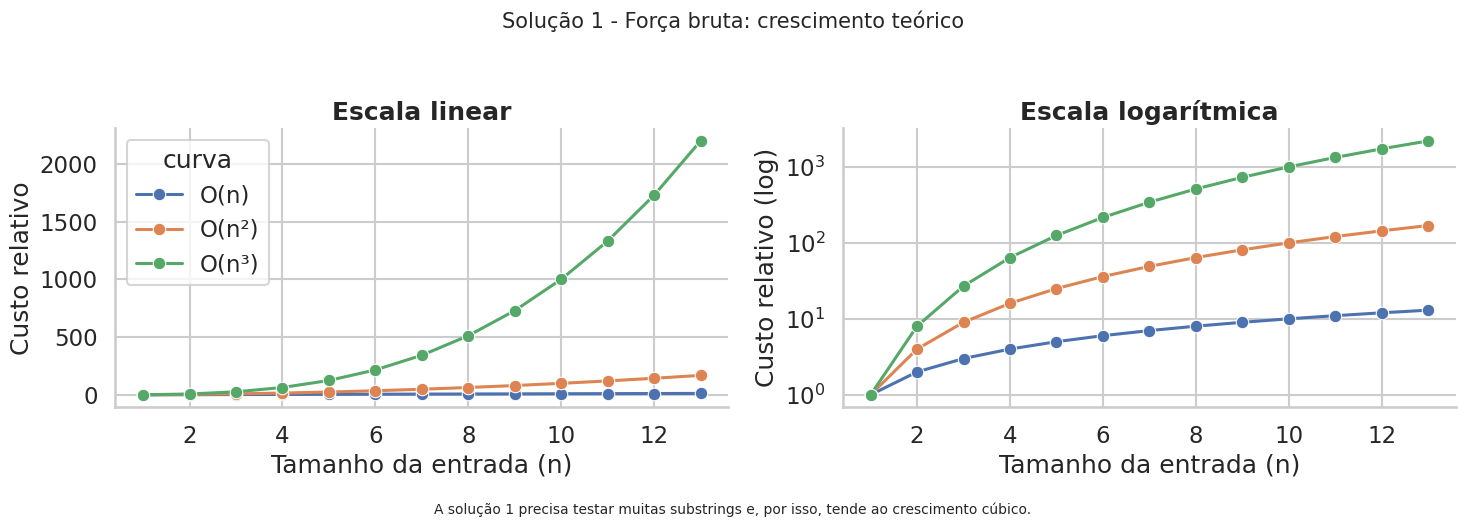

In [4]:
plotar_curvas_complexidade(
    titulo="Solução 1 - Força bruta: crescimento teórico",
    tamanhos=list(range(1, 14)),
    curvas={
        "O(n)": lambda n: n,
        "O(n²)": lambda n: n**2,
        "O(n³)": lambda n: n**3,
    },
    legenda_extra="A solução 1 precisa testar muitas substrings e, por isso, tende ao crescimento cúbico.",
)

## Solução 2 — Melhorada

### Descrição

A solução 2 continua sendo uma abordagem de força bruta, mas com uma melhoria importante: vamos procurar as
**substring mais longas primeiro**. Assim, assim que encontramos um palíndromo de certo tamanho, já sabemos que
não precisamos testar candidatos menores.

Além disso, em vez de construir cada substring com slicing antes de testar, podemos verificar o intervalo
diretamente com dois ponteiros. Isso reduz trabalho desnecessário e deixa a ideia mais eficiente sem mudar
a essência do método.

### O que foi melhorado

- na solução 1, varremos tudo e comparamos cada substring;
- na solução 2, começamos pelos comprimentos maiores e paramos cedo quando a resposta já foi encontrada;
- o pior caso continua ruim, mas o comportamento prático costuma melhorar bastante.


### ASCII sketch

```text
String:  b a b a d
Indices: 0 1 2 3 4

Teste por tamanho decrescente:
tamanho = 5 -> babad   (não)
tamanho = 4 -> baba    (não)
tamanho = 3 -> bab     (sim)  -> retorna cedo

Se bab não fosse encontrado, continuaríamos com:
tamanho = 3 -> aba     (sim)
```

Em `"cbbd"`, o primeiro palíndromo grande encontrado já é `"bb"`.
Em `"aaaa"`, o algoritmo encontra a string inteira logo no início e encerra imediatamente.


In [5]:
def longest_palindrome_bruteforce_improved(s: str) -> str:
    """
    Encontra a maior substring palíndroma com uma poda simples.

    A ideia é testar substrings do maior tamanho para o menor e parar assim que
    encontramos a primeira candidata palíndroma.

    Parâmetros:
    ----------
    s : str
        String de entrada.

    Retorno:
    -------
    str
        Maior substring palíndroma encontrada.

    Exceções:
    --------
    Levanta TypeError se `s` não for uma string.
    """
    if not isinstance(s, str):
        raise TypeError("A entrada deve ser uma string.")
    n = len(s)
    if n <= 1:
        return s

    for tamanho in range(n, 0, -1):
        for inicio in range(0, n - tamanho + 1):
            fim = inicio + tamanho - 1
            if eh_palindromo_intervalo(s, inicio, fim):
                return s[inicio : fim + 1]
    return s[0]

In [6]:
for caso in casos_teste:
    resposta = longest_palindrome_bruteforce_improved(caso["texto"])
    validar_resposta(
        caso["texto"],
        resposta,
        respostas_validas=caso["validas"],
        comprimento_esperado=caso["comprimento"],
    )

print("Todos os testes da solução 2 passaram.")

Todos os testes da solução 2 passaram.


### Complexidade

- **Tempo:** `O(n^3)` no pior caso. Continuamos podendo examinar muitos intervalos e cada verificação pode custar `O(n)`.
- **Espaço:** `O(1)`.

Mesmo sem mudar a ordem assintótica, essa evolução já é pedagogicamente útil porque mostra um padrão importante:
às vezes a primeira grande melhora vem de **podar o espaço de busca**, não de trocar totalmente o algoritmo.


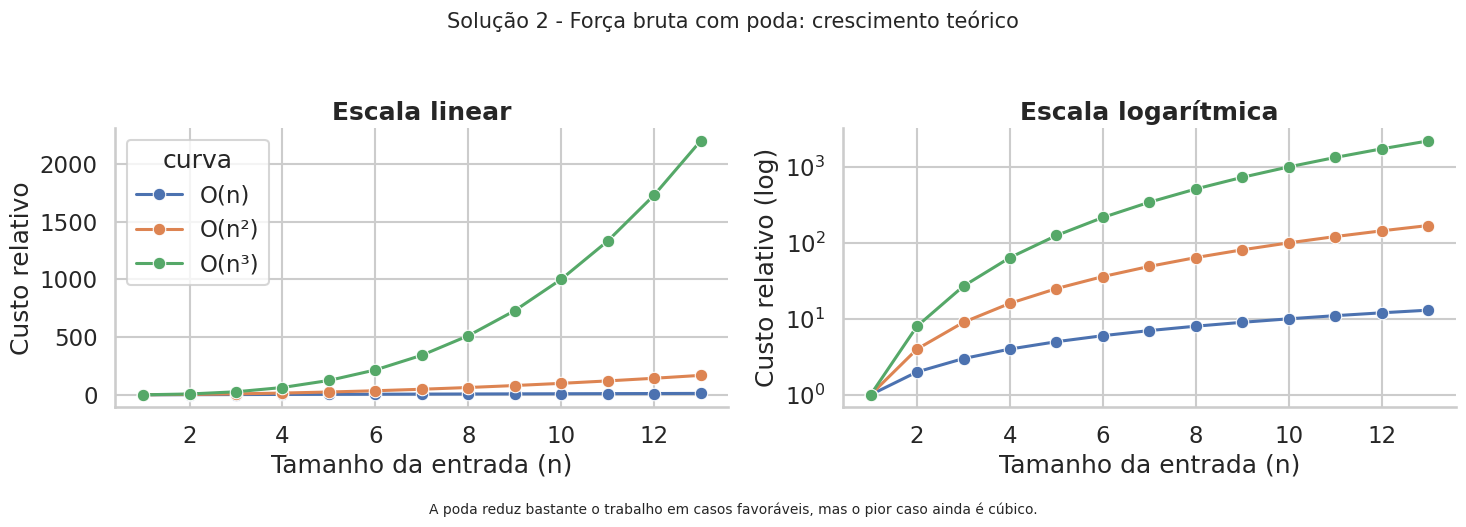

In [7]:
plotar_curvas_complexidade(
    titulo="Solução 2 - Força bruta com poda: crescimento teórico",
    tamanhos=list(range(1, 14)),
    curvas={
        "O(n)": lambda n: n,
        "O(n²)": lambda n: n**2,
        "O(n³)": lambda n: n**3,
    },
    legenda_extra="A poda reduz bastante o trabalho em casos favoráveis, mas o pior caso ainda é cúbico.",
)

## Solução 3 — Melhor solução possível

### Descrição

A abordagem mais prática e didática para esse problema é **expand around center**. A ideia é observar que todo
palíndromo tem um centro. Esse centro pode ser:

- **ímpar**, como em `"racecar"`, onde existe um caractere central;
- **par**, como em `"cbbd"`, onde o centro fica entre dois caracteres iguais.

Se tentarmos cada posição como centro e expandirmos para os lados enquanto os caracteres forem iguais, conseguimos
descobrir todos os palíndromos candidatos sem gerar todas as substrings.

Essa estratégia é um ótimo equilíbrio entre simplicidade e eficiência para entrevistas e para o LeetCode.


### ASCII sketch

```text
String:  b a b a d
Index :  0 1 2 3 4

Centro ímpar em 1:
          L R
          a
Expande -> b a b
           [0 1 2]

Centro ímpar em 2:
            L R
            b
Expande -> a b a
           [1 2 3]

Centro par entre 1 e 2 em "cbbd":
          b b
         L   R
Expande -> b b
           [1 2]
```

A grande sacada é perceber que não precisamos testar todos os intervalos possíveis.
Basta explorar os centros relevantes e expandir enquanto a simetria continuar válida.


In [8]:
def expandir_a_partir_do_centro(s: str, esquerda: int, direita: int) -> tuple[int, int]:
    """
    Expande um centro e devolve os limites do maior palíndromo encontrado.

    Parâmetros:
    ----------
    s : str
        String analisada.
    esquerda : int
        Índice inicial do centro.
    direita : int
        Índice final do centro.

    Retorno:
    -------
    tuple[int, int]
        Índices inicial e final do maior palíndromo ao redor do centro.

    Exceções:
    --------
    Levanta TypeError se `s` não for uma string.
    """
    if not isinstance(s, str):
        raise TypeError("A entrada deve ser uma string.")

    while esquerda >= 0 and direita < len(s) and s[esquerda] == s[direita]:
        esquerda -= 1
        direita += 1
    return esquerda + 1, direita - 1

def longest_palindrome_center_expand(s: str) -> str:
    """
    Encontra a maior substring palíndroma expandindo a partir de centros.

    Parâmetros:
    ----------
    s : str
        String de entrada.

    Retorno:
    -------
    str
        Maior substring palíndroma encontrada.

    Exceções:
    --------
    Levanta TypeError se `s` não for uma string.
    """
    if not isinstance(s, str):
        raise TypeError("A entrada deve ser uma string.")
    if len(s) <= 1:
        return s

    inicio_melhor = 0
    fim_melhor = 0
    for centro in range(len(s)):
        inicio1, fim1 = expandir_a_partir_do_centro(s, centro, centro)
        if fim1 - inicio1 > fim_melhor - inicio_melhor:
            inicio_melhor, fim_melhor = inicio1, fim1

        inicio2, fim2 = expandir_a_partir_do_centro(s, centro, centro + 1)
        if fim2 - inicio2 > fim_melhor - inicio_melhor:
            inicio_melhor, fim_melhor = inicio2, fim2

    return s[inicio_melhor : fim_melhor + 1]

In [9]:
for caso in casos_teste:
    resposta = longest_palindrome_center_expand(caso["texto"])
    validar_resposta(
        caso["texto"],
        resposta,
        respostas_validas=caso["validas"],
        comprimento_esperado=caso["comprimento"],
    )

print("Todos os testes da solução 3 passaram.")

Todos os testes da solução 3 passaram.


### Complexidade

- **Tempo:** `O(n^2)`. Para cada centro, podemos expandir até o limite da string.
- **Espaço:** `O(1)`.

Na prática, essa é a melhor combinação entre clareza e eficiência para este problema. Ela é curta o bastante para ser entendida
em entrevista e forte o bastante para lidar bem com `s.length <= 1000`.


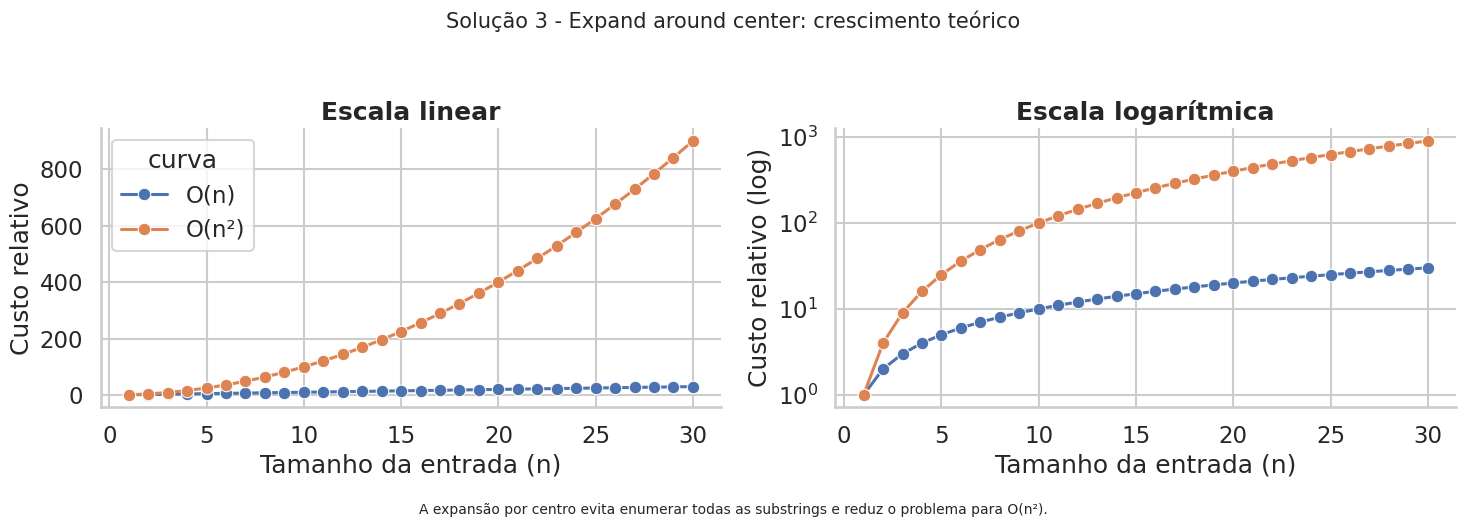

In [10]:
plotar_curvas_complexidade(
    titulo="Solução 3 - Expand around center: crescimento teórico",
    tamanhos=list(range(1, 31)),
    curvas={
        "O(n)": lambda n: n,
        "O(n²)": lambda n: n**2,
    },
    legenda_extra="A expansão por centro evita enumerar todas as substrings e reduz o problema para O(n²).",
)

## Solução 4 — Versão enxuta para submissão no LeetCode

### Descrição

Agora vamos transformar a solução 3 em uma versão mais compacta, com menos explicações inline e no formato clássico
que costuma ser aceito no LeetCode. A lógica continua a mesma: expandir a partir de centros ímpares e pares.


### ASCII sketch

```text
Mesmo raciocínio da solução 3:
- expandir em (i, i) para centros ímpares;
- expandir em (i, i+1) para centros pares;
- manter o melhor intervalo encontrado.
```

O objetivo aqui não é mudar o algoritmo, mas apenas deixar o código pronto para submissão.


In [11]:
class Solution:
    def longestPalindrome(self, s: str) -> str:
        """
        Resolve a maior substring palíndroma usando expansão a partir de centros.

        Parâmetros:
        ----------
        s : str
            String de entrada.

        Retorno:
        -------
        str
            Maior substring palíndroma encontrada.
        """
        if len(s) < 2:
            return s

        def expandir(esq: int, dir: int) -> tuple[int, int]:
            while esq >= 0 and dir < len(s) and s[esq] == s[dir]:
                esq -= 1
                dir += 1
            return esq + 1, dir - 1

        inicio, fim = 0, 0
        for i in range(len(s)):
            l1, r1 = expandir(i, i)
            if r1 - l1 > fim - inicio:
                inicio, fim = l1, r1
            l2, r2 = expandir(i, i + 1)
            if r2 - l2 > fim - inicio:
                inicio, fim = l2, r2
        return s[inicio : fim + 1]

In [12]:
solucao_leetcode = Solution()

for caso in casos_teste:
    resposta = solucao_leetcode.longestPalindrome(caso["texto"])
    validar_resposta(
        caso["texto"],
        resposta,
        respostas_validas=caso["validas"],
        comprimento_esperado=caso["comprimento"],
    )

print("Todos os testes da solução 4 passaram.")

Todos os testes da solução 4 passaram.


### Complexidade

- **Tempo:** `O(n^2)`, igual à solução 3.
- **Espaço:** `O(1)`.

A diferença aqui é apenas de formato. Em termos de algoritmo, a solução 4 reaproveita a mesma ideia da solução 3,
só que em um formato mais curto e típico de submissão.


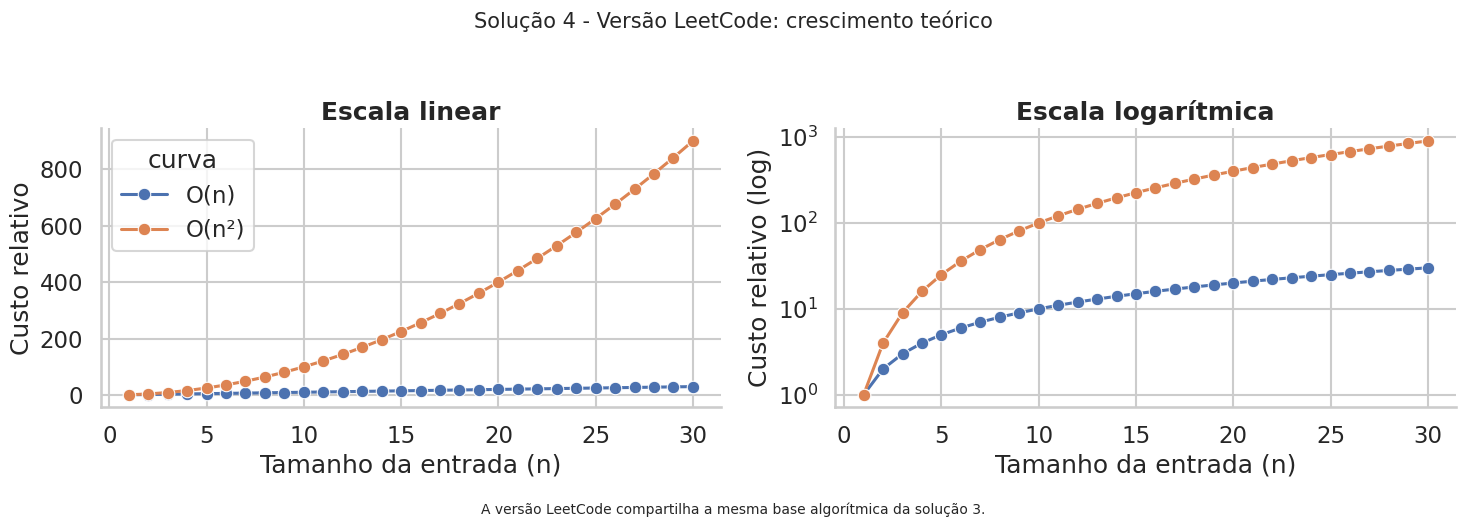

In [13]:
plotar_curvas_complexidade(
    titulo="Solução 4 - Versão LeetCode: crescimento teórico",
    tamanhos=list(range(1, 31)),
    curvas={
        "O(n)": lambda n: n,
        "O(n²)": lambda n: n**2,
    },
    legenda_extra="A versão LeetCode compartilha a mesma base algorítmica da solução 3.",
)

## Comparação entre as abordagens

Agora que temos as quatro soluções, vale compará-las lado a lado:

| Solução | Ideia principal | Tempo | Espaço | Comentário didático |
| --- | --- | --- | --- | --- |
| 1. Força bruta | Gerar todas as substrings e testar uma a uma | `O(n^3)` | `O(1)` | Correta, mas muito custosa |
| 2. Força bruta melhorada | Testar comprimentos em ordem decrescente e parar cedo | `O(n^3)` no pior caso | `O(1)` | Boa evolução natural da solução 1 |
| 3. Melhor solução | Expandir a partir dos centros | `O(n^2)` | `O(1)` | Melhor equilíbrio entre clareza e eficiência |
| 4. LeetCode enxuta | Mesma ideia da solução 3 em formato compacto | `O(n^2)` | `O(1)` | Pronta para submissão |

Se a meta fosse apenas ganhar ainda mais em assintótica, poderíamos citar o algoritmo de Manacher, que resolve
o problema em `O(n)`. Porém ele é bem mais difícil de explicar com clareza, então não foi usado como solução principal
neste notebook.


## Benchmark

Para fechar, vamos comparar as abordagens em cenários diferentes. Como a solução 1 pode ficar bem mais lenta,
vamos usar tamanhos moderados para evitar que o notebook trave. O objetivo aqui é didático, não de microotimização.

### Cenários usados

1. string aleatória sem palíndromo longo;
2. string com muitos caracteres repetidos;
3. string com um palíndromo grande no meio;
4. string quase sem repetição;
5. casos clássicos conhecidos.

Vamos medir o tempo médio e o desvio padrão em milissegundos usando `perf_counter`.


In [14]:
def gerar_string_aleatoria_sem_palindromo_longo(tamanho: int, seed: int = 42) -> str:
    """
    Gera uma string aleatória reprodutível para o benchmark.

    Parâmetros:
    ----------
    tamanho : int
        Comprimento da string gerada.
    seed : int, default = 42
        Semente usada para tornar a geração reprodutível.

    Retorno:
    -------
    str
        String aleatória gerada.

    Exceções:
    --------
    Levanta ValueError se `tamanho` for negativo.
    """
    if tamanho < 0:
        raise ValueError("O tamanho deve ser não negativo.")
    rng = random.Random(seed)
    alfabeto = "abcdefghi"
    return "".join(rng.choice(alfabeto) for _ in range(tamanho))

def gerar_string_repetida(tamanho: int) -> str:
    """
    Gera uma string com muitos caracteres repetidos.

    Parâmetros:
    ----------
    tamanho : int
        Comprimento da string gerada.

    Retorno:
    -------
    str
        String formada pela repetição de `"a"`.

    Exceções:
    --------
    Levanta ValueError se `tamanho` for negativo.
    """
    if tamanho < 0:
        raise ValueError("O tamanho deve ser não negativo.")
    return "a" * tamanho

def gerar_string_com_palindromo_no_meio(tamanho: int, seed: int = 99) -> str:
    """
    Gera uma string com um palíndromo grande concentrado no meio.

    Parâmetros:
    ----------
    tamanho : int
        Comprimento da string gerada.
    seed : int, default = 99
        Semente usada para tornar a geração reprodutível.

    Retorno:
    -------
    str
        String que contém um palíndromo central.

    Exceções:
    --------
    Levanta ValueError se `tamanho` for menor que 3.
    """
    if tamanho < 3:
        raise ValueError("O tamanho mínimo para esse cenário é 3.")
    rng = random.Random(seed + tamanho)
    pal_len = max(3, int(tamanho * 0.7))
    pal_len = min(pal_len, tamanho)
    sobra = tamanho - pal_len
    prefixo_len = sobra // 2
    sufixo_len = sobra - prefixo_len
    alfabeto = "abcdefg"
    prefixo = "".join(rng.choice(alfabeto) for _ in range(prefixo_len))
    sufixo = "".join(rng.choice(alfabeto) for _ in range(sufixo_len))
    meio_base = "".join(rng.choice(alfabeto) for _ in range(pal_len // 2))
    meio_central = rng.choice(alfabeto) if pal_len % 2 else ""
    palindromo = meio_base + meio_central + meio_base[::-1]
    return prefixo + palindromo + sufixo

def gerar_string_quase_sem_repeticao(tamanho: int) -> str:
    """
    Gera uma string com pouca repetição visual.

    Parâmetros:
    ----------
    tamanho : int
        Comprimento da string gerada.

    Retorno:
    -------
    str
        String montada a partir de caracteres alfanuméricos.

    Exceções:
    --------
    Levanta ValueError se `tamanho` for negativo.
    """
    if tamanho < 0:
        raise ValueError("O tamanho deve ser não negativo.")
    base = string.ascii_letters + string.digits
    return (base * ((tamanho // len(base)) + 1))[:tamanho]

def medir_funcao(
    funcao: Callable[[str], str],
    texto: str,
    repeticoes: int = 5,
) -> tuple[float, float]:
    """
    Mede o tempo médio e o desvio padrão de uma função.

    Parâmetros:
    ----------
    funcao : Callable[[str], str]
        Função que será medida.
    texto : str
        Entrada passada para a função.
    repeticoes : int, default = 5
        Quantidade de medições executadas.

    Retorno:
    -------
    tuple[float, float]
        Tempo médio em milissegundos e desvio padrão das medições.

    Exceções:
    --------
    Levanta ValueError se `repeticoes` for menor que 1.
    """
    if repeticoes < 1:
        raise ValueError("`repeticoes` deve ser pelo menos 1.")
    tempos = []
    for _ in range(repeticoes):
        inicio = perf_counter()
        funcao(texto)
        fim = perf_counter()
        tempos.append((fim - inicio) * 1000)
    serie = pd.Series(tempos, dtype="float64")
    return float(serie.mean()), float(serie.std(ddof=0))

def construir_casos_benchmark() -> list[dict[str, object]]:
    """
    Constrói os cenários usados no benchmark final.

    Parâmetros:
    ----------
    Nenhum.

    Retorno:
    -------
    list[dict[str, object]]
        Lista com cenários clássicos e sintéticos do benchmark.

    Exceções:
    --------
    Levanta ValueError nas funções auxiliares de geração caso os tamanhos sejam inválidos.
    """
    tamanhos = [10, 20, 40, 60, 80, 100]
    casos: list[dict[str, object]] = []

    for tamanho in tamanhos:
        casos.append(
            {
                "cenario": "Aleatória",
                "entrada": f"n={tamanho}",
                "texto": gerar_string_aleatoria_sem_palindromo_longo(tamanho, seed=100 + tamanho),
                "tamanho": tamanho,
            }
        )
        casos.append(
            {
                "cenario": "Repetidos",
                "entrada": f"n={tamanho}",
                "texto": gerar_string_repetida(tamanho),
                "tamanho": tamanho,
            }
        )
        casos.append(
            {
                "cenario": "Palíndromo central",
                "entrada": f"n={tamanho}",
                "texto": gerar_string_com_palindromo_no_meio(tamanho, seed=200 + tamanho),
                "tamanho": tamanho,
            }
        )
        casos.append(
            {
                "cenario": "Quase sem repetição",
                "entrada": f"n={tamanho}",
                "texto": gerar_string_quase_sem_repeticao(tamanho),
                "tamanho": tamanho,
            }
        )

    casos_classicos = {
        "babad": "babad",
        "cbbd": "cbbd",
        "racecar": "racecar",
        "forgeeksskeegfor": "forgeeksskeegfor",
        "aaaa": "aaaa",
    }
    for rotulo, texto in casos_classicos.items():
        casos.append(
            {
                "cenario": "Clássicos",
                "entrada": rotulo,
                "texto": texto,
                "tamanho": len(texto),
            }
        )

    return casos

def executar_benchmark(
    funcoes: dict[str, Callable[[str], str]],
    casos: list[dict[str, object]],
    repeticoes: int = 5,
) -> pd.DataFrame:
    """
    Executa o benchmark das funções sobre os casos fornecidos.

    Parâmetros:
    ----------
    funcoes : dict[str, Callable[[str], str]]
        Dicionário com os nomes das soluções e suas funções.
    casos : list[dict[str, object]]
        Lista de cenários a serem avaliados.
    repeticoes : int, default = 5
        Quantidade de medições por caso.

    Retorno:
    -------
    pd.DataFrame
        Tabela com os tempos médios e desvios padrão por cenário.

    Exceções:
    --------
    Levanta ValueError se `repeticoes` for menor que 1.
    """
    registros: list[dict[str, object]] = []
    for nome_solucao, funcao in funcoes.items():
        for caso in casos:
            tempo_medio_ms, desvio_padrao_ms = medir_funcao(funcao, str(caso["texto"]), repeticoes=repeticoes)
            registros.append(
                {
                    "solucao": nome_solucao,
                    "cenario": caso["cenario"],
                    "entrada": caso["entrada"],
                    "tamanho": int(caso["tamanho"]),
                    "tempo_medio_ms": tempo_medio_ms,
                    "desvio_padrao_ms": desvio_padrao_ms,
                }
            )
    return pd.DataFrame(registros)

In [15]:
funcoes_benchmark = {
    "1. Força bruta": longest_palindrome_bruteforce,
    "2. Melhorada": longest_palindrome_bruteforce_improved,
    "3. Centro expandido": longest_palindrome_center_expand,
    "4. LeetCode enxuta": Solution().longestPalindrome,
}

casos_benchmark = construir_casos_benchmark()
df_benchmark = executar_benchmark(funcoes_benchmark, casos_benchmark, repeticoes=5)
df_benchmark = df_benchmark.sort_values(["cenario", "tamanho", "solucao", "entrada"]).reset_index(drop=True)

display(df_benchmark.head(15))

,solucao,cenario,entrada,tamanho,tempo_medio_ms,desvio_padrao_ms
0,1. Força bruta,Aleatória,n=10,10,0.012557,0.002445
1,2. Melhorada,Aleatória,n=10,10,0.003853,0.001438
2,3. Centro expandido,Aleatória,n=10,10,0.004234,0.001302
3,4. LeetCode enxuta,Aleatória,n=10,10,0.003871,0.001290
4,1. Força bruta,Aleatória,n=20,20,0.028214,0.000916
5,2. Melhorada,Aleatória,n=20,20,0.013521,0.000492
6,3. Centro expandido,Aleatória,n=20,20,0.006153,0.000321
7,4. LeetCode enxuta,Aleatória,n=20,20,0.005897,0.000386
8,1. Força bruta,Aleatória,n=40,40,0.108919,0.000819
9,2. Melhorada,Aleatória,n=40,40,0.048534,0.002896


In [16]:
df_resumo = (
    df_benchmark
    .groupby(["cenario", "solucao"], as_index=False)
    .agg(
        tempo_medio_ms=("tempo_medio_ms", "mean"),
        desvio_padrao_ms=("desvio_padrao_ms", "mean"),
        tamanho_medio=("tamanho", "mean"),
    )
    .sort_values(["cenario", "tempo_medio_ms"])
)

display(df_resumo)

,cenario,solucao,tempo_medio_ms,desvio_padrao_ms,tamanho_medio
3,Aleatória,4. LeetCode enxuta,0.014178,0.000628,51.666667
2,Aleatória,3. Centro expandido,0.014851,0.000581,51.666667
1,Aleatória,2. Melhorada,0.125028,0.005144,51.666667
0,Aleatória,1. Força bruta,0.277911,0.002703,51.666667
5,Clássicos,2. Melhorada,0.001222,0.000345,7.200000
7,Clássicos,4. LeetCode enxuta,0.002408,0.000376,7.200000
6,Clássicos,3. Centro expandido,0.002513,0.000347,7.200000
4,Clássicos,1. Força bruta,0.007138,0.000813,7.200000
11,Palíndromo central,4. LeetCode enxuta,0.015578,0.001052,51.666667
9,Palíndromo central,2. Melhorada,0.015794,0.000275,51.666667


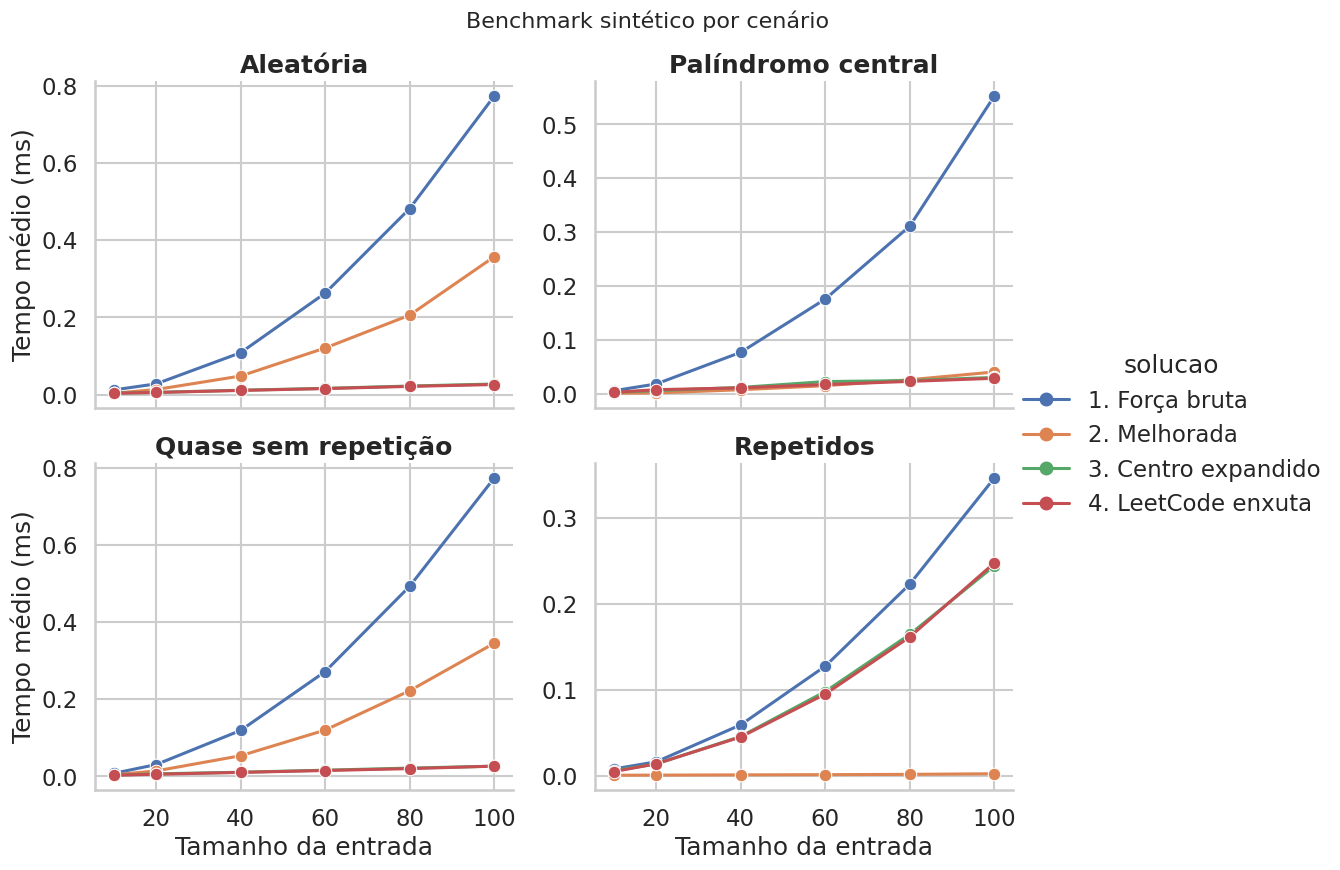

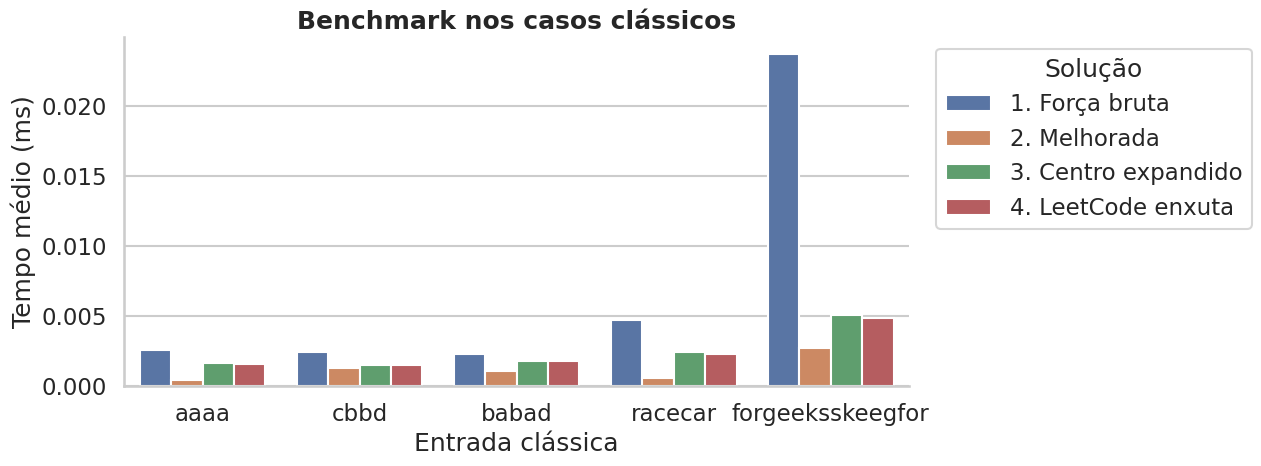

In [17]:
df_sintetico = df_benchmark[df_benchmark["cenario"] != "Clássicos"].copy()
df_classicos = df_benchmark[df_benchmark["cenario"] == "Clássicos"].copy()

g = sns.relplot(
    data=df_sintetico,
    x="tamanho",
    y="tempo_medio_ms",
    hue="solucao",
    col="cenario",
    kind="line",
    marker="o",
    facet_kws={"sharey": False},
    col_wrap=2,
    height=4.3,
    aspect=1.25,
    linewidth=2.2,
)
g.set_axis_labels("Tamanho da entrada", "Tempo médio (ms)")
g.set_titles("{col_name}")
g.fig.suptitle("Benchmark sintético por cenário", y=1.02, fontsize=16)
plt.show()

plt.figure(figsize=(13, 5))
sns.barplot(
    data=df_classicos,
    x="entrada",
    y="tempo_medio_ms",
    hue="solucao",
    errorbar=None,
)
plt.title("Benchmark nos casos clássicos")
plt.xlabel("Entrada clássica")
plt.ylabel("Tempo médio (ms)")
plt.legend(title="Solução", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretação dos resultados

O benchmark deve mostrar a mesma história que a análise teórica já contava:

- a solução 1 tende a ser a mais lenta, porque verifica muitas substrings;
- a solução 2 melhora a prática ao parar cedo, mas ainda sofre no pior caso;
- a solução 3 costuma ser a mais eficiente de forma consistente;
- a solução 4 deve ficar muito próxima da solução 3, porque compartilha o mesmo núcleo algorítmico.

Também vale lembrar que pequenas oscilações são normais. Benchmark em notebook sofre influência do interpretador,
da máquina e do estado do ambiente.


## Conclusão

A evolução das quatro soluções mostra bem um padrão clássico em problemas de algoritmo:

1. começar pela versão mais óbvia para garantir entendimento;
2. melhorar a busca com podas simples quando possível;
3. observar a estrutura do problema para chegar a uma solução realmente eficiente;
4. transformar a melhor ideia em uma versão curta e pronta para submissão.

Para este problema, **expand around center** é a escolha ideal entre clareza e desempenho.
Se um dia quisermos ir além no aspecto assintótico, podemos estudar o algoritmo de Manacher como alternativa `O(n)`,
mas ele é bem menos didático para uma primeira leitura.

Este notebook fica assim pronto para estudo, revisão e publicação no Jupyter Book.
